In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection,benchmark_functional_groups, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster,evaluate_hdbscan_grid

projection_method = "UMAP"

In [3]:
qm9 = QM9Dataset(limit=5000, descriptors=["morgan"])
df = qm9.load()
X = np.array(df["morgan_fingerprint"].to_list())

2026-05-09 14:39:36.307 | INFO     | src.datasets:_load_full_qm9_df:816 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-09 14:39:36.810 | INFO     | src.datasets:_sample_qm9_df:999 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000, sampling on columns=['num_atoms', 'gap'].
2026-05-09 14:39:36.811 | INFO     | src.datasets:_add_requested_descriptors:201 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-09 14:39:36.811 | INFO     | src.features:compute_morgan_fingerprints:225 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-05-09 14:39:45.839 | INFO     | src.datasets:_add_requested_descriptors:212 - Added descriptor column(s): ['morgan_fingerprint']


In [4]:
X = np.array(df['morgan_fingerprint'].to_list())

In [6]:
dist_matrix = qm9.get_distance_matrix(descriptor="morgan", dist_type="jaccard")

2026-05-09 14:39:54.750 | INFO     | src.datasets:get_distance_matrix:1325 - Calculating distance matrix for morgan using jaccard distance.


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:07<00:00,  1.30it/s]


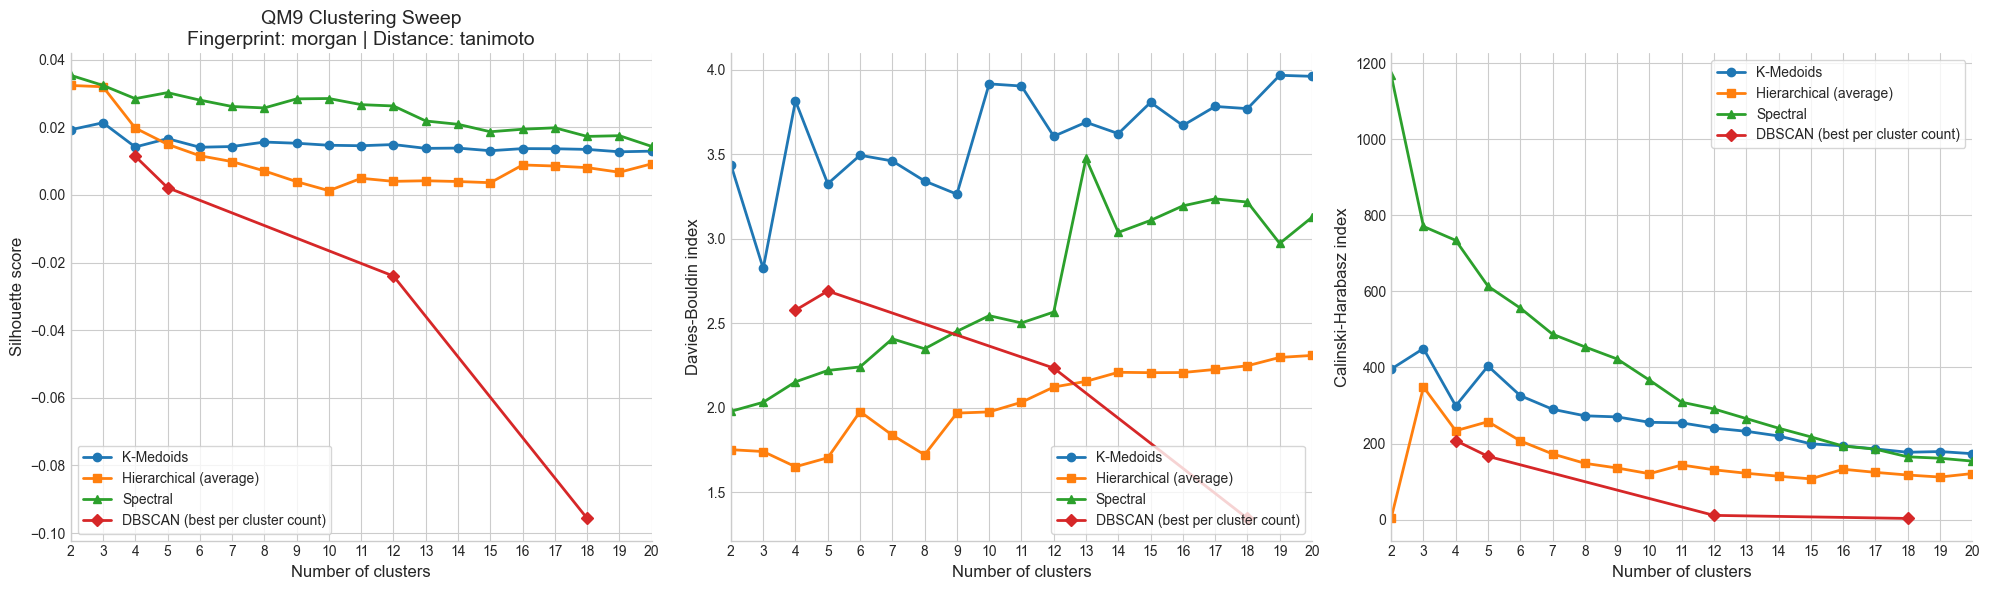

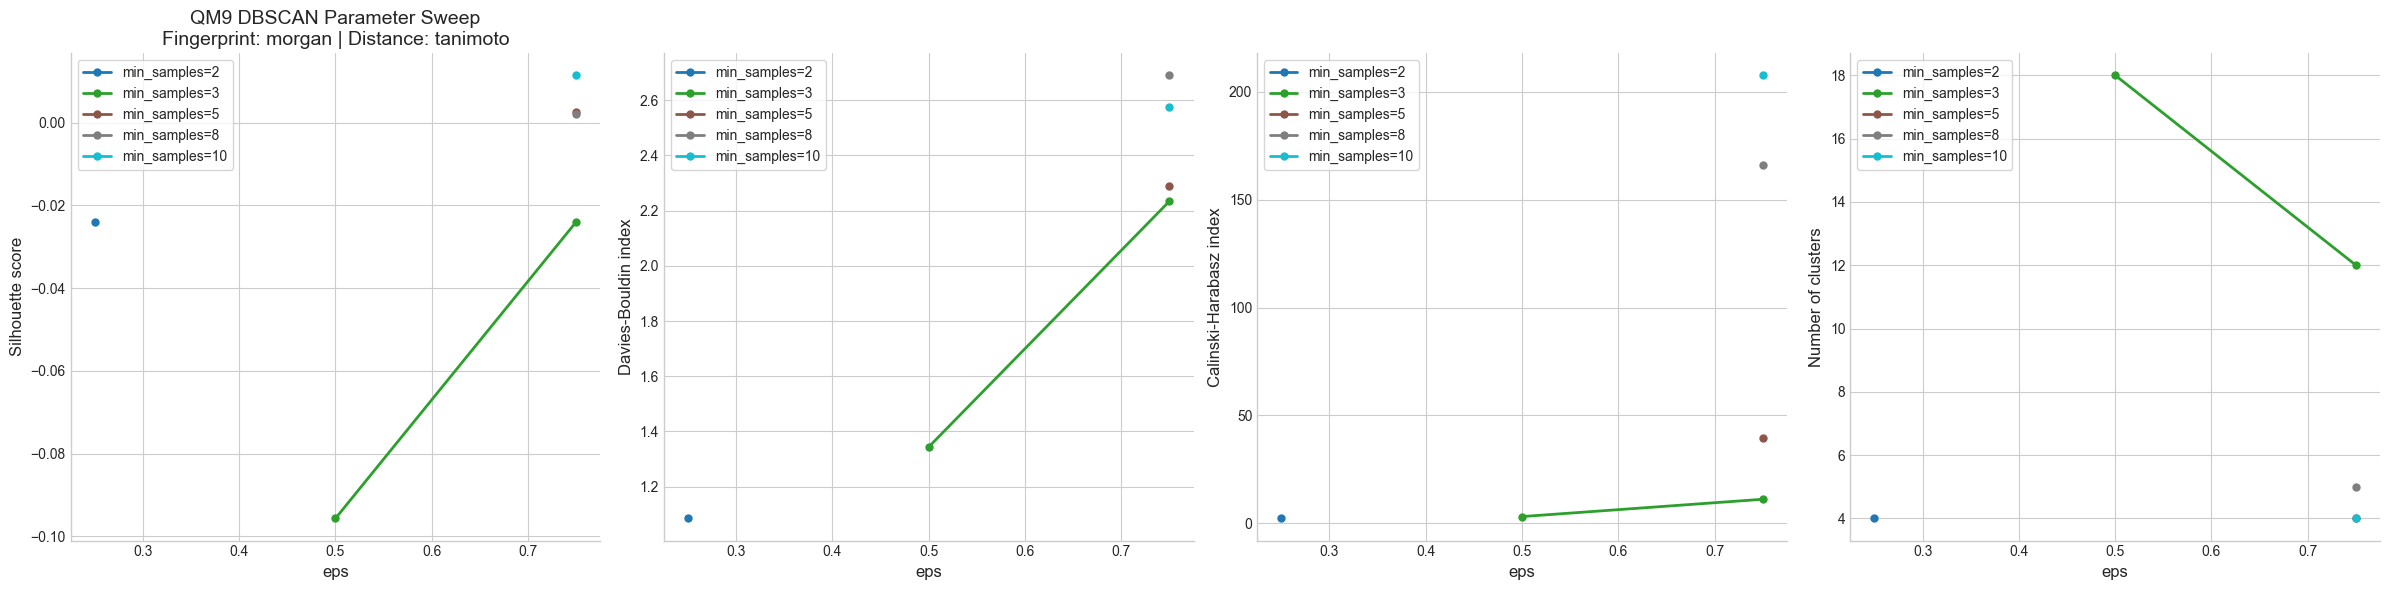

2026-05-07 17:24:40.845 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1060 - Saved clustering sweep plot to figures/qm9/clustering/tanimoto/morgan/clustering_sweep_2_to_20_clusters.png
2026-05-07 17:24:40.845 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved DBSCAN evaluation plot to figures/qm9/clustering/tanimoto/morgan/dbscan_parameter_sweep.png
2026-05-07 17:24:40.845 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1063 - Saved clustering sweep results to figures/qm9/clustering/tanimoto/morgan/clustering_sweep_2_to_20_clusters.json


In [ ]:
# out = evaluate_distance_matrix_clustering_sweep(
#     dist_matrix=dist_matrix,
#     fingerprint="morgan",
#     distance_metric="tanimoto",
#     dataset_name="qm9",
# )

# Hiercical Clustering on Distance Matrix

In [12]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=6, linkage='average')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2, 3, 4, 5]), array([4104,   12,  881,    1,    1,    1]))


In [14]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'UMAP')

2026-05-09 14:41:00.623 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running UMAP dimensionality reduction...
2026-05-09 14:41:00.624 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-09 14:41:47.550 | INFO     | src.helper_functions:create_chemiscope_viewer:1221 - Assembling properties for Chemiscope...
2026-05-09 14:41:47.554 | INFO     | src.helper_funct

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


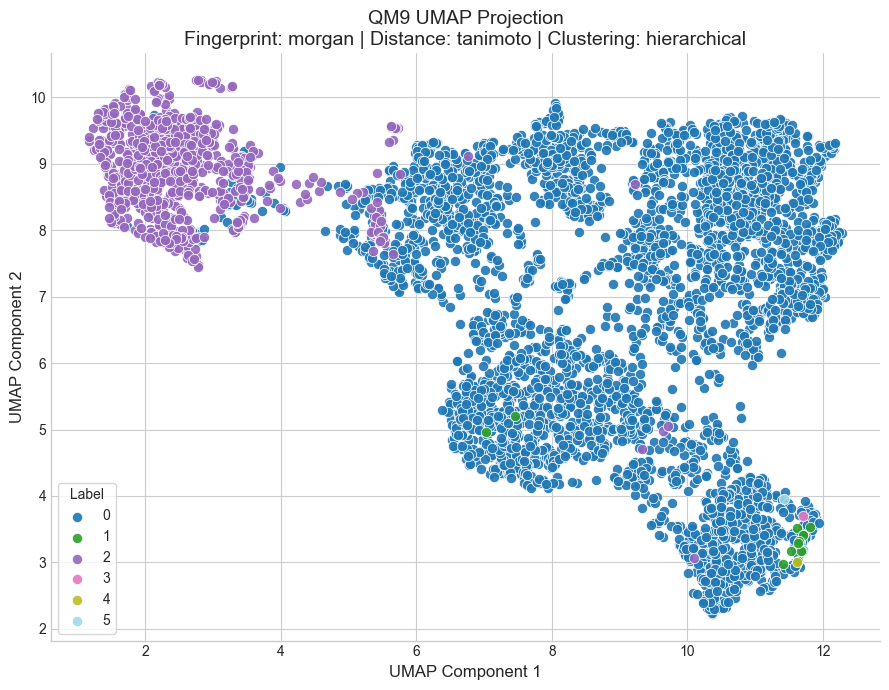

2026-05-09 14:40:57.110 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved UMAP projection plot to figures/qm9/clustering/tanimoto/morgan/umap_hierarchical_projection.png


In [ ]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method='t-SNE',
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [13]:
average_numeric_by_cluster(df, "labels_hier")

shape: (5, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,3899,0.759226,0.0,122.906899,0.017697,33.210823,0.895723,12.826434,8.786612,1.867145,0.022826,0.010259,2.252372,18.774301,2.080628,2.129264,0.06028,0.149026,0.790695,0.884842,1.843037,6.674788,0.404463,0.901513,5.228264,6.267504,14.012311,1.265711,0.000256,0.379328,0.002565,0.100539,0.149526,0.002052,0.042062,0.140549,0.596307,0.0,2.605782,75.469477,-6.569137,0.434533,7.003705,1170.662409,4.18698,-11111.074586,-11110.844262,-11110.818571,-11111.981316,31.799581,-77.493192,-77.97358,-78.421838,-72.096808,3.317969,1.432687,1.159284,90.536035,2.282637,7.181329,14.012311,1297,"""Acyclic""",7.181329,320,"""C1CC1""",10.541164,1,null,0.0
1,299,0.629227,0.0,123.036789,0.344482,39.591973,0.874776,12.882399,8.705686,0.217391,0.003344,0.020067,2.361204,19.521739,1.916167,4.866221,0.198547,0.092117,0.709337,0.792642,2.033445,5.32107,1.294314,0.521739,4.528428,7.311037,12.010033,1.236278,0.0,0.505017,0.0,0.137124,0.046823,0.0,0.033445,0.110368,0.628763,0.0,2.708059,77.833713,-7.051307,0.38237,7.433523,1523.669058,4.399003,-11105.429407,-11105.150789,-11105.125095,-11106.41246,35.996742,-79.288581,-79.753291,-80.223338,-73.730119,3.67268,1.020733,0.842454,16.722408,0.334448,82.943144,12.010033,20,"""Acyclic""",82.943144,11,"""Acyclic""",82.943144,1,null,0.0
2,794,0.828206,0.0,121.619647,0.201511,50.560453,0.664527,12.972016,8.774559,1.232997,1.010076,0.089421,3.478589,15.531486,2.029987,2.076826,0.042742,0.682568,0.27469,1.117128,2.836272,6.104534,0.241814,3.527708,1.526448,6.448363,12.596977,1.257804,0.02267,0.120907,0.186398,0.268262,0.028967,0.0,0.007557,0.020151,0.156171,0.006297,3.084432,72.691448,-6.084774,-0.349988,5.734813,1154.222279,3.27954,-11492.481659,-11492.265827,-11492.240146,-11493.378154,29.072727,-67.751771,-68.132019,-68.503791,-63.192006,4.026181,1.410737,1.028791,3.778338,96.221662,0.0,12.596977,259,"""c1c[nH]cn1""",8.060453,28,"""C1CCCC1""",49.370277,1,null,0.0
3,3,0.778537,0.0,116.666667,2.0,0.0,0.96073,12.647685,8.666667,3.0,0.0,0.0,0.0,21.333333,2.18813,0.0,0.0,0.074074,0.925926,0.0,0.0,8.666667,0.0,0.666667,8.0,6.0,16.666667,1.259418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1505,84.756668,-6.299436,1.806836,8.105365,1059.926575,5.171569,-9187.233398,-9187.026042,-9187.0,-9188.101888,31.168999,-89.320185,-89.935262,-90.457914,-83.085983,3.242723,1.77576,1.505573,100.0,0.0,0.0,16.666667,3,"""C1CC2(C1)CC1(CC1)C2""",33.333333,3,"""C1CC23CCC12CC3""",33.333333,1,null,0.0
4,5,0.720814,0.0,120.6,-1.2,55.8,0.52643,13.120469,8.6,1.8,0.0,0.0,3.6,17.6,2.086687,0.8,0.0,0.42,0.58,2.2,2.4,7.2,0.0,2.0,3.0,5.8,12.6,1.256619,0.0,0.0,0.0,1.2,0.0,0.0,0.0,0.2,0.0,0.0,3.55754,68.606,-6.261884,-1.346419,4.916009,877.286267,2.988529,-10972.065039,-10971.879102,-10971.85332,-10972.914648,26.1392,-62.319079,-62.688139,-63.032503,-58.03677,3.377692,2.10815,1.483044,100.0,0.0,0.0,12.6,5,"""[CH+]1NCC[NH2+]1""",20.0,5,"""C1CCCCCCCC1

In [14]:
benchmark_functional_groups(df, "labels_hier")

[{'Cluster': 0,
  'Size': 3899,
  'Top_FG_1': 'fr_ether (49.3%)',
  'Top_FG_2': 'fr_alcohol (32.0%)',
  'Top_FG_3': 'fr_ketone (13.4%)'},
 {'Cluster': 1,
  'Size': 299,
  'Top_FG_1': 'fr_ether (50.2%)',
  'Top_FG_2': 'fr_alcohol (42.1%)',
  'Top_FG_3': 'fr_amine (13.4%)'},
 {'Cluster': 2,
  'Size': 794,
  'Top_FG_1': 'fr_amine (22.8%)',
  'Top_FG_2': 'fr_phenol (17.1%)',
  'Top_FG_3': 'fr_ether (15.2%)'},
 {'Cluster': 3,
  'Size': 3,
  'Top_FG_1': 'fr_benzene (0.0%)',
  'Top_FG_2': 'fr_alcohol (0.0%)',
  'Top_FG_3': 'fr_phenol (0.0%)'},
 {'Cluster': 4,
  'Size': 5,
  'Top_FG_1': 'fr_amine (100.0%)',
  'Top_FG_2': 'fr_ketone (20.0%)',
  'Top_FG_3': 'fr_benzene (0.0%)'}]

# KMedoids

In [15]:
model_km = KMedoids(n_clusters=2, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [16]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-05-07 17:29:44.704 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 17:29:44.704 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 17:30:37.241 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 17:30:37.245 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 17:30:37.484 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 17:30:37.552 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

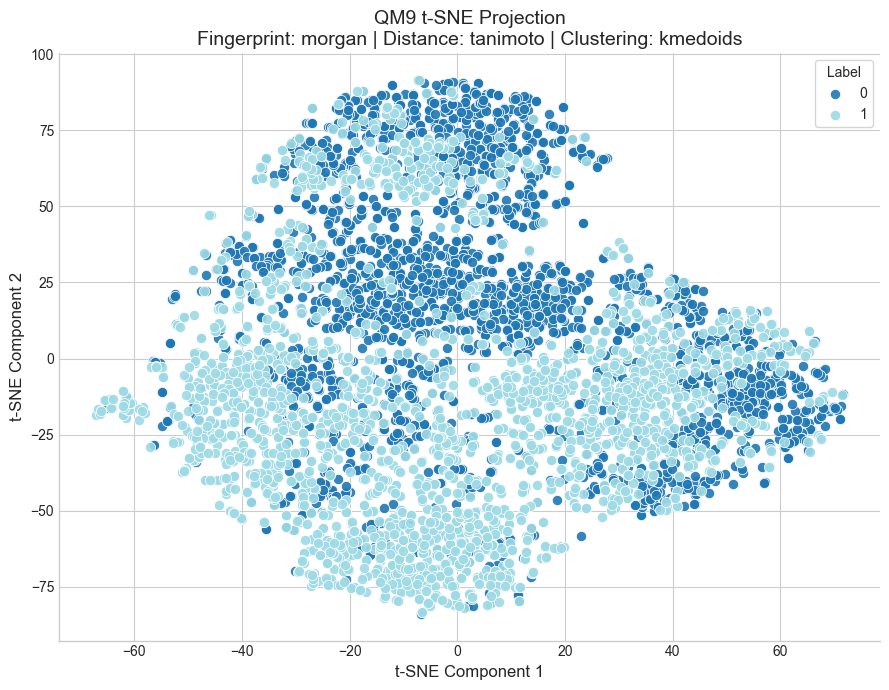

2026-05-09 14:42:54.399 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved t-SNE projection plot to figures/qm9/clustering/tanimoto/morgan/t_sne_kmedoids_projection.png


In [16]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method='t-SNE',
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [18]:
average_numeric_by_cluster(df, "labels_km")

shape: (2, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2972,0.752024,0.0,122.829408,0.048452,34.223755,0.880932,12.836495,8.784657,1.819314,0.073015,0.013459,2.217026,18.986878,2.073647,2.451884,0.076378,0.133682,0.78994,1.043069,1.850606,6.578735,0.506393,0.784657,5.276581,6.382907,14.055518,1.262169,0.002019,0.51144,0.035666,0.112046,0.080417,0.001682,0.013459,0.055182,0.524563,0.0,2.444294,76.102039,-6.559673,0.681959,7.24167,1188.464598,4.251629,-11040.811942,-11040.577246,-11040.551544,-11041.722526,32.407268,-77.997818,-78.482269,-78.936162,-72.542222,3.339555,1.401605,1.145418,0.213661,81.628533,7.166891,11.204576,14.055518,854,"""Acyclic""",11.204576,205,"""C1CC1""",11.877524,1,null,0.0
1,2028,0.777555,0.0,122.52071,0.092702,39.466469,0.82298,12.8774,8.772189,1.447239,0.33284,0.037968,2.800296,17.304241,2.046959,2.033037,0.049969,0.37257,0.577461,0.732249,2.247535,6.396943,0.321006,2.047337,3.60355,6.321499,13.100099,1.263435,0.00641,0.101578,0.025641,0.157298,0.18787,0.001479,0.069034,0.214004,0.531558,0.002465,3.043635,73.800207,-6.463303,-0.245273,6.21803,1189.295709,3.76672,-11359.350382,-11359.125163,-11359.099489,-11360.258511,30.445335,-73.184511,-73.61735,-74.030472,-68.180064,3.615948,1.411079,1.083111,0.631657,58.77712,31.607495,9.615385,13.100099,868,"""Acyclic""",9.615385,196,"""C1CCCC1""",18.836292,1,null,0.0


# Spectral

In [19]:
kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )
# 
labels_spectral = model_spectral.fit_predict(kernel)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

KeyboardInterrupt: 

In [ ]:
# create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

In [ ]:
labels_km

array([19, 16,  1, ..., 16, 16, 19], shape=(5000,), dtype=uint64)

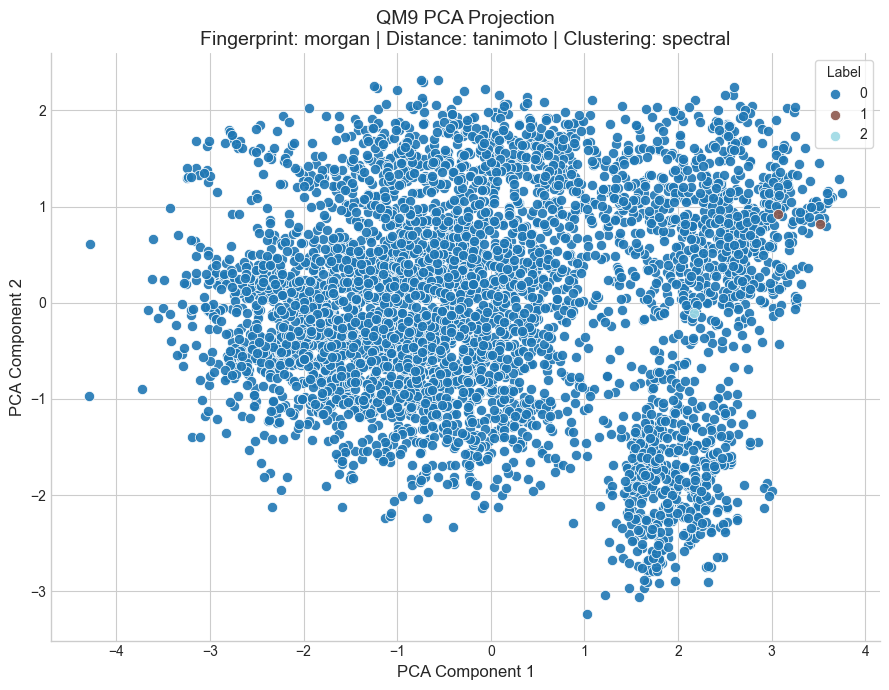

2026-05-07 13:47:57.094 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_spectral_projection.png


{'coords': array([[ 1.73608812, -1.93505213],
        [ 1.4120263 , -1.1809183 ],
        [ 1.08101742,  2.10470239],
        ...,
        [ 2.11681917, -0.91255404],
        [ 1.70180246, -1.40664182],
        [ 2.77070226, -1.44613484]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'spectral'}

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [ ]:
# average_numeric_by_cluster(df, "labels_spectral")

# DBSCAN 

In [ ]:
model_db = DBSCAN(
    eps=0.8,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1]), array([  25, 4972,    3]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-07 13:47:57.542 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 13:47:57.543 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 13:49:23.037 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 13:49:23.099 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 13:49:25.761 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 13:49:25.868 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

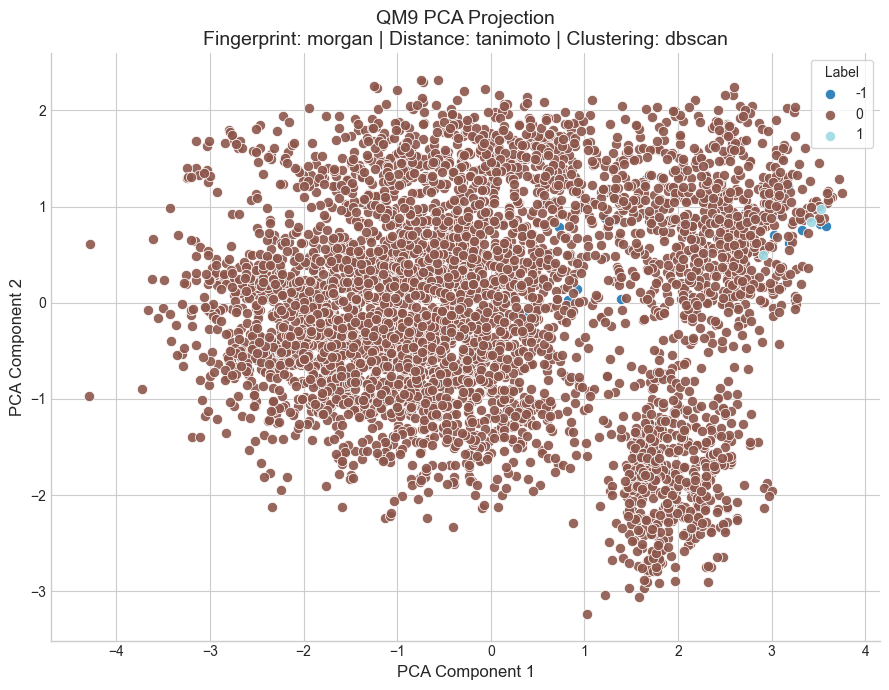

2026-05-07 13:49:26.799 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_dbscan_projection.png


{'coords': array([[ 1.73608812, -1.93505213],
        [ 1.4120263 , -1.1809183 ],
        [ 1.08101742,  2.10470239],
        ...,
        [ 2.11681917, -0.91255404],
        [ 1.70180246, -1.40664182],
        [ 2.77070226, -1.44613484]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'dbscan'}

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [ ]:
clusters = average_numeric_by_cluster(df, "labels_db")
clusters.show(limit=25)

shape: (3, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,25,0.842006,0.0,120.84,-0.16,49.52,0.480259,13.071647,8.76,1.84,0.6,0.04,3.68,15.96,2.107339,0.8,0.008889,0.658603,0.332508,1.32,2.64,6.72,0.08,3.12,1.88,6.24,12.92,1.266932,0.0,0.08,0.08,0.48,0.0,0.0,0.0,0.0,0.12,0.0,2.908964,71.7328,-6.094806,-0.819607,5.274982,956.411296,2.999932,-11155.190391,-11155.006797,-11154.981133,-11156.036016,26.01644,-63.614496,-63.987464,-64.332851,-59.298577,3.841476,1.812959,1.272131,1.4,9.2,0.16,56.0,44.0,0.0,12.92,24,"""C1=CN=CN=C[CH-]1""",8.0,11,"""C1CC2CCCC2C1""",40.0,1,null,0.0
0,4972,0.761799,0.0,122.717619,0.068383,36.261464,0.860038,12.851474,8.779968,1.667337,0.175181,0.023331,2.445093,18.320193,2.062532,2.290628,0.065992,0.228059,0.705949,0.914924,2.007039,6.504827,0.433226,1.287409,4.61424,6.359212,13.672566,1.262655,0.003821,0.346742,0.031376,0.128721,0.124698,0.001609,0.036203,0.120274,0.529767,0.001006,2.684482,75.197432,-6.522131,0.312539,6.834694,1190.240131,4.061565,-11169.860376,-11169.629238,-11169.603547,-11170.770344,31.64639,-76.126798,-76.590894,-77.028827,-70.848155,3.448657,1.402923,1.119127,0.312148,9.355792,0.0,72.485921,16.89461,10.619469,13.672566,1507,"""Acyclic""",10.619469,324,"""C1CCCC1""",12.771521,1,null,0.0
1,3,1.060606,0.0,116.0,-1.333333,73.666667,-0.328185,13.703316,8.333333,2.0,2.0,0.0,6.333333,11.666667,2.172494,0.333333,0.0,0.833333,0.166667,1.0,4.333333,5.0,0.0,1.666667,0.333333,5.333333,12.333333,1.273552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.6543,55.71,-7.505807,-1.360569,6.145238,741.423482,1.883908,-11543.372396,-11543.221354,-11543.195964,-11544.185872,20.426666,-44.966348,-45.226117,-45.474485,-41.720773,5.180303,2.19417,1.54305,2.0,12.0,0.0,0.0,100.0,0.0,12.333333,3,"""n1nc2[nH+]nnn2[nH]1""",33.333333,1,"""C1CC2CCCC2C1""",100.0,1,null,0.0


# HDBSCAN

In [ ]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=220, ms=1, clusters=2, noise=0.15, persistence=0.045, score=0.038
mcs=300, ms=1, clusters=2, noise=0.15, persistence=0.044, score=0.037
mcs=150, ms=1, clusters=2, noise=0.15, persistence=0.043, score=0.036
mcs=120, ms=1, clusters=2, noise=0.15, persistence=0.043, score=0.036
mcs=80, ms=1, clusters=2, noise=0.15, persistence=0.038, score=0.032
mcs=150, ms=10, clusters=2, noise=0.38, persistence=0.023, score=0.014
mcs=10, ms=2, clusters=2, noise=0.01, persistence=0.014, score=0.014
mcs=120, ms=60, clusters=2, noise=0.22, persistence=0.014, score=0.011
mcs=120, ms=30, clusters=2, noise=0.35, persistence=0.016, score=0.011
mcs=60, ms=10, clusters=2, noise=0.09, persistence=0.011, score=0.010
mcs=60, ms=1, clusters=4, noise=0.25, persistence=0.013, score=0.010
mcs=80, ms=40, clusters=2, noise=0.13, persistence=0.011, score=0.010
mcs=80, ms=40, clusters=2, noise=0.13, persistence=0.011, score=0.010
mcs=60, ms=6, clusters=2, noise=0.12, persistence=0.011, score=0.010

In [ ]:
hdbscan = HDBSCAN(min_cluster_size=150, min_samples=10, metric='precomputed')
labels_hdbscan = hdbscan.fit_predict(dist_matrix.astype(np.float64))
df= df.with_columns(labels_hdbscan=labels_hdbscan)
print(np.unique(labels_hdbscan, return_counts=True))

(array([-1,  0,  1]), array([1898, 2886,  216]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'UMAP')

2026-05-07 16:00:39.204 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running UMAP dimensionality reduction...
2026-05-07 16:00:39.206 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-07 16:01:49.434 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 16:01:49.453 | INFO     | src.helper_funct

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

In [ ]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (3, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,773,0.811325,0.0,122.996119,-0.037516,39.637775,0.740735,12.911676,8.866753,1.871928,0.456662,0.051746,2.921087,17.187581,2.091741,1.394567,0.030575,0.436971,0.532453,0.96119,2.225097,6.74903,0.187581,2.390686,3.3674,6.219922,13.601552,1.267751,0.018111,0.155239,0.03881,0.227684,0.111255,0.007762,0.028461,0.055627,0.393273,0.0,2.948287,74.508862,-6.256447,-0.174607,6.08184,1107.779043,3.662356,-11309.656643,-11309.447459,-11309.421794,-11310.539351,29.170101,-71.953706,-72.388155,-72.791621,-67.020322,3.592251,1.511946,1.147438,0.761966,8.834411,0.005175,-0.028461,56.532988,41.397154,2.069858,13.601552,560,"""Acyclic""",2.069858,147,"""C1CCCC1""",14.747736,1,null,0.0
0,3676,0.745526,0.0,122.802231,0.069369,33.436888,0.905934,12.824741,8.765506,1.713547,0.000272,0.008977,2.209739,18.928727,2.064677,2.452394,0.075256,0.120638,0.804106,0.86235,1.841132,6.521491,0.50272,0.73803,5.315016,6.362894,13.8716,1.262982,0.0,0.418118,0.0,0.082971,0.139554,0.000544,0.042437,0.148259,0.60691,0.0,2.586325,75.648079,-6.649445,0.490344,7.139813,1206.11996,4.244906,-11090.00536,-11089.768849,-11089.743154,-11090.920974,32.395576,-78.040133,-78.522199,-78.975713,-72.596253,3.341607,1.387715,1.13309,0.003808,9.169478,0.0,0.0,86.044614,0.027203,13.928183,13.8716,993,"""Acyclic""",13.928183,275,"""Acyclic""",13.928183,1,null,0.0
1,551,0.806149,0.0,121.640653,0.192377,51.174229,0.697516,12.959992,8.751361,1.08167,0.976407,0.079855,3.424682,15.705989,2.009877,2.3902,0.050918,0.67447,0.274613,1.219601,2.849365,6.052632,0.295826,3.490018,1.540835,6.519056,12.402904,1.253573,0.009074,0.125227,0.232305,0.310345,0.038113,0.0,0.00363,0.018149,0.185118,0.009074,2.995597,72.89363,-6.031456,-0.25075,5.78075,1186.929782,3.33843,-11507.860944,-11507.637442,-11507.611745,-11508.768041,29.805652,-68.479056,-68.859607,-69.236712,-63.873177,3.988639,1.374346,0.995505,1.796733,11.337568,0.0,0.0,3.266788,96.733212,0.0,12.402904,107,"""c1c[nH]cn1""",11.433757,22,"""C1CCCC1""",63.157895,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


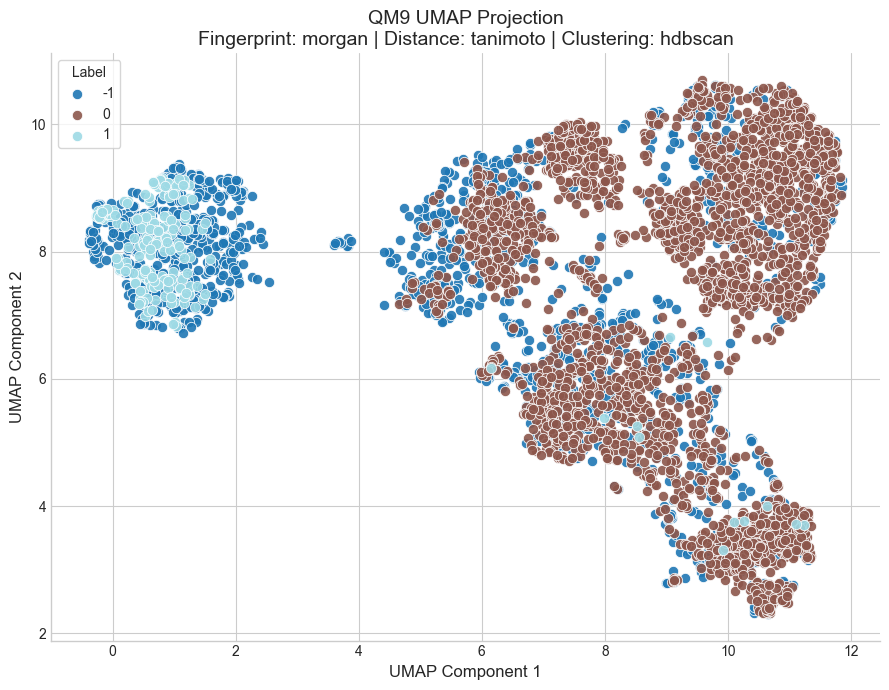

2026-05-07 15:57:41.814 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved UMAP projection plot to figures/qm9/clustering/tanimoto/morgan/umap_hdbscan_projection.png


In [ ]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

# KMeans on embedding

In [ ]:
df

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,is_injected,outlier_category,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,…,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,coordinates,atomic_numbers,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan
str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,list[list[f64]],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],i64,u64,i32,i64,i64
"""qm9_21""","""C3H8O""","""[H]OC([H])(C([H])([H])[H])C([H…","""CC(C)O""","""Acyclic""","""Acyclic""","""Acyclic""","""[4*]C([H])(C([H])([H])[H])C([H…","""""","""[C][C][Branch1][C][C][O]""","""alcohol""","""Acyclic""",0,null,60,0,20,0.940086,13.015533,4,0,0,0,1,12,1.833333,3,0.0,0.0,1.0,1,1,3,0,0,3,4,…,0,1,0,0,0,0,0,0,0,0,"[[-0.0332, 1.5478, -0.0044], [-0.0111, 0.0186, 0.0168], … [-1.8182, -0.1558, -0.6955]]","[6, 6, … 1]",1.4259,38.580002,-7.107614,2.013643,9.118535,318.372101,2.929931,-5286.280273,-5286.131348,-5286.105469,-5287.026855,19.052,-45.175072,-45.4883,-45.77108,-42.007965,8.67553,8.00568,4.75542,"[0, 1, … 0]",0,19,0,0,0
"""qm9_34""","""C3H6O""","""[H]C(=O)C([H])([H])C([H])([H])…","""CCC=O""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C(=O)C([H])([H])C([H])([H])…","""""","""[C][C][C][=O]""","""""","""Acyclic""",0,null,58,0,17,0.977264,12.898953,4,0,0,0,1,10,1.8,2,0.0,0.333333,0.666667,0,1,3,0,1,2,4,…,0,0,0,0,0,0,0,0,0,0,"[[0.1688, 1.5251, -0.1575], [-0.1874, 0.0619, 0.1468], … [0.3538, 0.2066, 2.2887]]","[6, 6, … 1]",2.6741,35.830002,-6.802846,-0.557833,6.245013,333.327606,2.290518,-5253.84375,-5253.705566,-5253.679688,-5254.594727,15.954,-39.964523,-40.211521,-40.442844,-37.381725,26.145639,4.2893,4.12773,"[0, 0, … 0]",0,16,0,0,0
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""O=C1CNC1""","""O=C1CNC1""","""CC1CCC1""","""*=*1***1""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[O][=C][C][N][C][Ring1][Ring2]""","""ketone""","""Aliphatic Ring""",0,null,71,0,29,0.761845,12.992522,5,1,0,0,2,10,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,…,0,0,0,0,0,0,0,1,0,0,"[[0.0005, 0.0067, -0.0974], [-0.0137, 1.1921, 0.0314], … [1.5674, 2.4713, -0.8115]]","[8, 6, … 1]",2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,"[0, 0, … 0]",0,1,0,0,0
"""qm9_99""","""C4H8O""","""[H]C([H])([H])[C@]1([H])O[C@]1…","""C[C@@H]1O[C@@H]1C""","""C1CO1""","""C1CC1""","""*1**1""","""[13*][C@]1([H])O[C@@]1([13*])[…","""[H]C([H])([H])[C@]1([H])O[C@]1…","""[C][C@@H1][O][C@@H1][Ring1][Ri…","""ether""","""Aliphatic Ring""",0,null,72,0,12,0.964858,12.880514,5,1,0,0,1,13,2.0,2,0.0,0.0,1.0,0,1,4,0,0,4,5,…,0,0,0,0,0,0,0,0,1,0,"[[-0.0335, 1.5467, -0.1337], [-0.0497, 0.0591, 0.1086], … [2.2815, -0.578, 2.5896]]","[6, 6, … 1]",1.8159,46.02,-7.001489,2.6776,9.67909,432.222412,3.07973,-6322.14209,-6321.982422,-6321.956543,-6322.920898,20.451,-51.173328,-51.514725,-51.823193,-47.643005,8.15202,4.38313,3.43318,"[0, 0, … 0]",0,13,0,0,0
"""qm9_231""","""C4H5NO""","""[H]C#CC([H])([H])C(=O)N([H])[H…","""C#CCC(N)=O""","""Acyclic""","""Acyclic""","""Acyclic""","""[5*]N([H])[H],[1*]C(=O)C([H])(…","""""","""[C][#C][C][C][Branch1][C][N][=…","""amine,amide""","""Acyclic""",0

In [ ]:
embedding = np.array(df['morgan_fingerprint'].to_list())
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(embedding)
df = df.with_columns(kmeans_labels=kmeans_labels)

In [ ]:
create_chemiscope_viewer(df, embedding, kmeans_labels, 'PCA')

2026-05-07 13:51:34.312 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 13:51:34.313 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 13:52:42.480 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 13:52:42.487 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 13:52:42.815 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 13:52:42.907 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
average_numeric_by_cluster(df, "kmeans_labels")

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

kmeans_labels,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,983,0.834831,0.0,122.85351,-0.096643,39.747711,0.884871,12.830227,8.796541,1.788403,0.143438,0.02238,2.76297,16.93998,2.084431,1.348932,0.026514,0.334727,0.638759,0.77823,2.238047,6.57884,0.167854,1.93591,3.929807,5.866734,13.914547,1.274211,0.002035,0.209563,0.006104,0.090539,0.280773,0.001017,0.137335,0.429298,…,3.369019,71.799074,-6.525276,-0.503336,6.021941,1079.394317,3.654812,-11504.478431,-11504.263063,-11504.237389,-11505.368163,29.701859,-72.464175,-72.893093,-73.297013,-67.543525,3.194879,1.556424,1.181883,0.230926,8.094608,0.0,-0.003052,-0.175992,85.757884,14.242116,0.0,13.914547,579,"""O=C1CCO1""",2.950153,148,"""CC1CCCC1""",12.410987,1,null,0.0
1,2688,0.744002,0.0,123.032366,0.078869,29.579613,0.900084,12.816458,8.808408,2.106399,0.002232,0.004464,2.017857,19.462798,2.102013,2.18564,0.059888,0.077749,0.862363,0.891741,1.668527,6.853795,0.412202,0.517113,5.861235,6.311384,14.270833,1.266344,0.0,0.422247,0.0,0.09189,0.058036,0.001488,0.005208,0.024554,…,2.318453,76.807117,-6.564805,0.871723,7.436571,1163.892404,4.383665,-10944.791714,-10944.561617,-10944.535921,-10945.695312,32.139089,-79.448775,-79.95335,-80.417596,-73.869455,3.202982,1.434157,1.185561,0.010417,7.781622,0.000744,-0.002232,-0.091518,99.776786,0.223214,0.0,14.270833,805,"""C1CC1""",7.849702,203,"""C1CC1""",14.955357,1,null,0.0
2,1329,0.745957,0.0,121.930023,0.161776,47.531226,0.75085,12.944075,8.708804,0.693755,0.560572,0.062453,3.106095,16.970655,1.967572,3.167043,0.106314,0.462641,0.431046,1.07073,2.537998,5.744921,0.664409,2.401053,2.537246,6.815651,12.266366,1.24675,0.012792,0.289691,0.114372,0.237773,0.14146,0.002257,0.023326,0.082769,…,2.929408,74.34617,-6.427677,-0.240062,6.187613,1320.106161,3.686065,-11378.143899,-11377.900065,-11377.874375,-11379.080291,31.956916,-71.811219,-72.217288,-72.624987,-66.898627,4.144557,1.235712,0.942178,1.006772,13.475546,0.001505,-0.009782,0.148232,6.997743,53.273138,39.72912,12.266366,206,"""Acyclic""",39.72912,24,"""Acyclic""",39.72912,1,null,0.0
